<a href="https://colab.research.google.com/github/zcflanzer/rcew-water-budget/blob/main/updated_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook created by Zoe Flanzer


> Last updated: 1/4/2026

This notebook compiles and organizes prior notebooks assessing and plotting RCEW water budget.

==> Some edits still need to be made/added

# Setting up the notebook

## Mounting Google Drive and importing important libraries

In [1]:
## mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from google.colab import files
import math

## Importing data

In [3]:
## importing csv's of water budget variables
# annual data
Q_data_ann = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Discharge/Q_ann_2000andOn.csv') # includes years: 2000 - 2024
ET_data_ann = pd.read_csv('/content/drive/MyDrive/Thesis/Data/ET/annual_ET.csv') # includes years: 2000 - 2024
P_data_ann = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Precip/annual_precip_depth_cm.csv') # includes years: 2000 - 2023

# monthly data
P_data_mon = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Precip/monthly_precip_depth_cm_MS.csv') # includes years: 2000 - 2023
ET_data_mon = pd.read_csv('/content/drive/MyDrive/Thesis/Data/ET/monthly_ET.csv') # includes years: 2000 - 2024
Q_data_mon = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Discharge/Q_mon_2000andOn.csv') # includes years: 2000 - 2024+

In [31]:
## Defining specific variables: aligned to only include the 2000 - 2023 water years for all variables
# Q
Q_yr = Q_data_ann['discharge_yr'].iloc[:24] # water year
Q_cm_ann = Q_data_ann['discharge_cm'].iloc[:24] # cm
Q_mo = pd.to_datetime(Q_data_mon['Date'].iloc[:288]) # date, converting to datetime
Q_cm_mon = Q_data_mon['Discharge_cm'].iloc[:288] # cm

# ET
ET_yr = ET_data_ann['et_yr'].iloc[:24] # water year
ET_cm_ann = ET_data_ann['et_cm'].iloc[:24] # cm
ET_mo = pd.to_datetime(ET_data_mon['date'].iloc[:288]) # date, converting to datetime
ET_cm_mon = ET_data_mon['ET_cm'].iloc[:288] # cm

# P
P_yr = P_data_ann['water_year'].iloc[:24] # water year
P_cm_ann = P_data_ann['avg_precip_cm'].iloc[:24] # cm
P_mo = pd.to_datetime(P_data_mon['time'].iloc[:288]) # date, converting to datetime
P_cm_mon = P_data_mon['avg_precip_cm'].iloc[:288] # cm

In [5]:
## Importing vegetation cover data
## Data from USDA Rangeland Analysis Platform: https://rangelands.app/rap/?landcover_t=pfg&ll=34.9828,-89.2769&z=5
veg_data = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Vegetation/cover.csv')

# defining specific variables and aligning to only include 2000 to 2023
veg_yr = veg_data['year'].iloc[14:38]
afg = veg_data['AFG'].iloc[14:38]
pfg = veg_data['PFG'].iloc[14:38]
shr = veg_data['SHR'].iloc[14:38]
tre = veg_data['TRE'].iloc[14:38]
ltr = veg_data['LTR'].iloc[14:38]
bgr = veg_data['BGR'].iloc[14:38]
annualtemp_rap =  veg_data['annualTemp'].iloc[14:38]
annualprecip_rap = veg_data['annualPrecip'].iloc[14:38]

***********NEED TO ADD TO SPREADSHEET WITH UNITS AND YEARS***********

In [6]:
snow_cover = [29.50, 43.27,  42.02, 27.05, 36.81, 30.29, 36.77, 30.01, 40.46, 46.10, 40.91, 32.83, 34.27, 40.02,  27.35, 25.61, 38.73, 34.37, 29.42, 32.06, 36.14, 40.76, 39.38, 39.12, 34.59, 41.87]

In [7]:
## Importing precip temp data (XX)
P_temp_data = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Snow/wy_precip_temp_summary.csv')

P_temp_yr = P_temp_data['water_year'].iloc[:24]
P_temp_C = P_temp_data['avg_precip_temp_C'].iloc[:24]

# Correlation coefficients + analyses

In [8]:
## Pearson correlation coefficient and p value
P_YET, p_value_YET = pearsonr(ET_yr, ET_cm_ann) # ET by year
P_YQ, p_value_YQ = pearsonr(Q_yr, Q_cm_ann) # Q by year
P_YP, p_value_YP = pearsonr(P_yr, P_cm_ann) # P by year

# printing
print(f'ET: r = {P_YET}, p = {p_value_YET}')
print(f'Q: r = {P_YQ}, p = {p_value_YQ}')
print(f'P: r = {P_YP}, p = {p_value_YP}')

ET: r = 0.5926603262633525, p = 0.0022748639587828554
Q: r = 0.04436877957838664, p = 0.8369009653580783
P: r = 0.16764065577940407, p = 0.4336323301683011


In [9]:
## Spearman correlation coefficiant and p value
S_YET, s_value_YET = spearmanr(ET_yr, ET_cm_ann) # ET by year
S_YQ, s_value_YQ = spearmanr(Q_yr, Q_cm_ann) # Q by year
S_YP, s_value_YP = spearmanr(P_yr, P_cm_ann) # P by year

# printing
print(f'ET: r = {S_YET}, p = {s_value_YET}')
print(f'Q: r = {S_YQ}, p = {s_value_YQ}')
print(f'P: r = {S_YP}, p = {s_value_YP}')

ET: r = 0.6304347826086956, p = 0.0009590059599017164
Q: r = 0.08608695652173912, p = 0.6891799258775774
P: r = 0.1973913043478261, p = 0.3552078904108176


# Plotting annual data

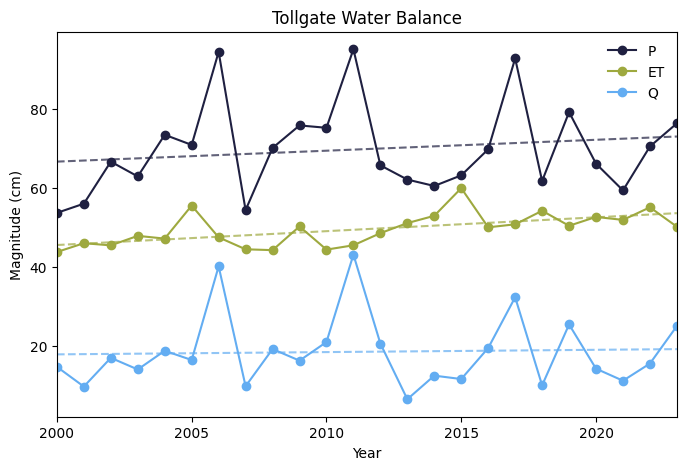

In [10]:
## plotting annual water budget
Water_Budget = plt.figure(figsize=(8, 5))

plt.plot(P_yr, P_cm_ann, label='P', marker='o', color='#1F2041') # plotting P
plt.plot(ET_yr, ET_cm_ann, label='ET', marker='o', color='#9EA93F') # plotting ET
plt.plot(Q_yr, Q_cm_ann, label='Q', marker='o', color='#63ADF2') # plotting Q

# optional: add trendlines to plot (comment to exclude/uncomment to include)
# P trend
coef_P = np.polyfit(P_yr, P_cm_ann, 1)   # slope, intercept
trend_P = np.polyval(coef_P, P_yr)
plt.plot(P_yr, trend_P, linestyle='--', color='#1F2041', alpha=0.7)

# ET trend
coef_ET = np.polyfit(ET_yr, ET_cm_ann, 1)
trend_ET = np.polyval(coef_ET, ET_yr)
plt.plot(ET_yr, trend_ET, linestyle='--', color='#9EA93F', alpha=0.7)

# Q trend
coef_Q = np.polyfit(Q_yr, Q_cm_ann, 1)
trend_Q = np.polyval(coef_Q, Q_yr)
plt.plot(Q_yr, trend_Q, linestyle='--', color='#63ADF2', alpha=0.7)

# adding labels
plt.xlim(2000, 2023)
plt.title('Tollgate Water Balance')
plt.xlabel('Year')
plt.ylabel('Magnitude (cm)')
plt.legend(frameon=False)
plt.show

Water_Budget.savefig('Water_Budget_Annual.png') # saving fig

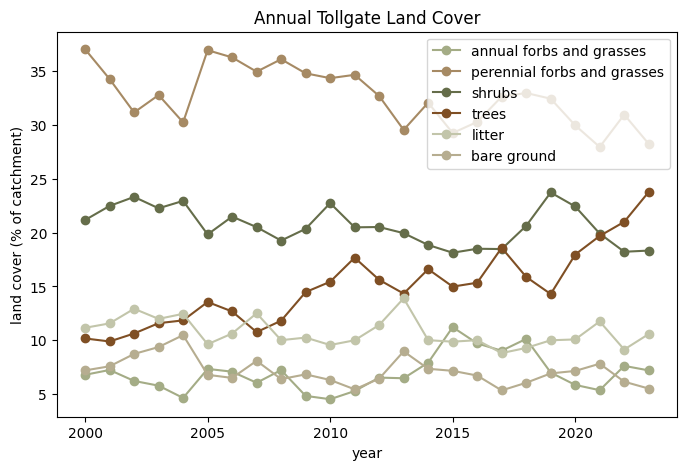

In [11]:
## plotting annual vegetation cover by type
vegcover_fig = plt.figure(figsize=(8, 5))

plt.plot(veg_yr, afg, label='annual forbs and grasses', marker='o', color='#A4AC86') # plotting annual forbes and grasses
plt.plot(veg_yr, pfg, label='perennial forbs and grasses', marker='o', color='#A68A64') # plotting perennial forbs and grasses
plt.plot(veg_yr, shr, label='shrubs', marker='o', color='#656D4A') # plotting shrubs
plt.plot(veg_yr, tre, label='trees', marker='o', color='#7F4F24') # plotting trees
plt.plot(veg_yr, ltr, label='litter', marker='o', color='#C2C5AA') # plotting litter
plt.plot(veg_yr, bgr, label='bare ground', marker='o', color='#B6AD90') # plotting bare ground

# labeling
plt.xlabel('year')
plt.ylabel('land cover (% of catchment)')
plt.title('Annual Tollgate Land Cover')
plt.legend()

vegcover_fig.savefig('vegcover.png') # saving figure

# Plotting monthly data

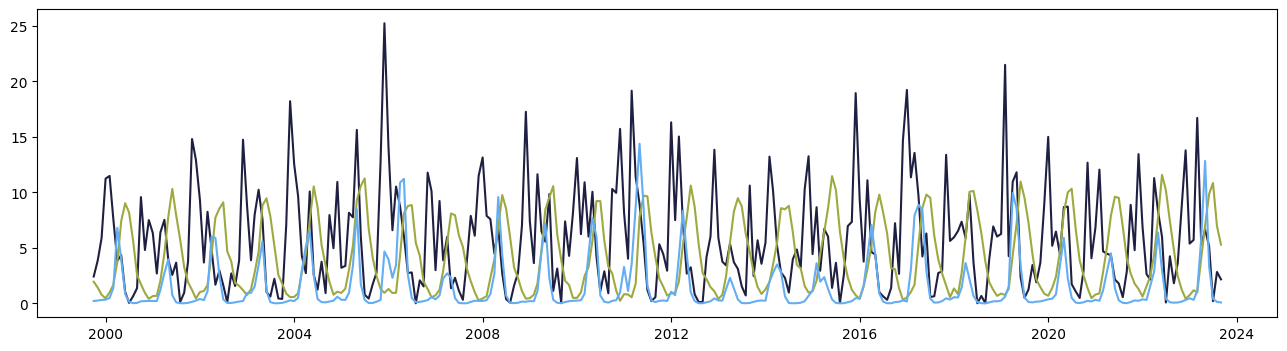

In [32]:
## plotting all monthly variables
Water_Budget_mon = plt.figure(figsize=(16, 4))

plt.plot(P_mo, P_cm_mon, label='P', marker=None, color='#1F2041') # plotting P
plt.plot(ET_mo, ET_cm_mon, label='ET', marker=None, color='#9EA93F') # plotting ET
plt.plot(Q_mo, Q_cm_mon, label='Q', marker=None, color='#63ADF2') # plotting Q

In [67]:
## converting instantaneous monthly measurements to cumulative sums
# function to convert to cumulative measurements
def cumsum_wy(df, value_col, start_month=0):
  data = df.copy() # copying data
  data['water_year'] = data.index.year + (data.index.month >= start_month).astype(int) # defining water year: if month >= start month, the water year is year + 1
  data['cumulative'] = data.groupby('water_year')[value_col].cumsum() # computing cumulative sum for each water year
  return data

# combining monthly dates and magnitudes into a data frame to convert to cumulative monthly data
P_df = pd.DataFrame({'date': P_mo,'P_cm': P_cm_mon}).set_index('date')
ET_df = pd.DataFrame({'date': ET_mo,'ET_cm': ET_cm_mon}).set_index('date')
Q_df = pd.DataFrame({'date': Q_mo,'Q_cm': Q_cm_mon}).set_index('date')

# applying cumulative sum function to data frames
P_cum = cumsum_wy(P_df, 'P_cm', start_month=10)
ET_cum = cumsum_wy(ET_df, 'ET_cm', start_month=10)
Q_cum = cumsum_wy(Q_df, 'Q_cm', start_month=10)

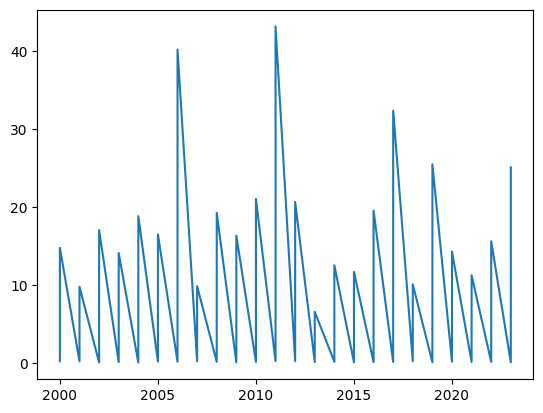

In [68]:
plt.plot(Q_cum['water_year'], Q_cum['cumulative'])

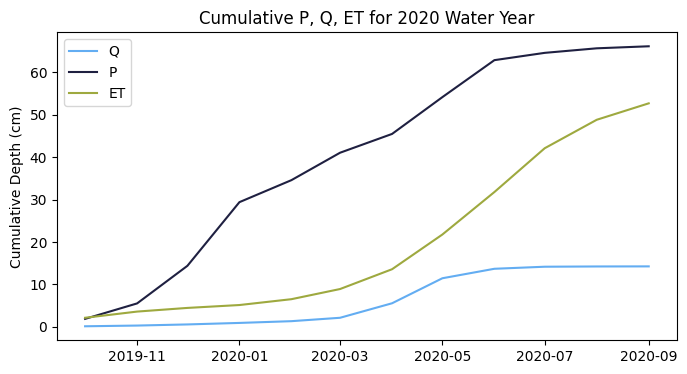

In [71]:
## plotting cumulative sums of one select water year
wy = 2020 # change year here

# filtering so that only the designated water year is used
Q_cum_wy = Q_cum[Q_cum['water_year'] == wy]
P_cum_wy = P_cum[P_cum['water_year'] == wy]
ET_cum_wy = ET_cum[ET_cum['water_year'] == wy]

# plotting
plt.figure(figsize=(8, 4))
plt.plot(Q_cum_wy.index, Q_cum_wy['cumulative'], label='Q', marker=None, color='#63ADF2') # Q
plt.plot(P_cum_wy.index, P_cum_wy['cumulative'], label='P', marker=None, color='#1F2041') # P
plt.plot(ET_cum_wy.index, ET_cum_wy['cumulative'], label='ET', marker=None, color='#9EA93F') # ET

# labeling
plt.ylabel('Cumulative Depth (cm)')
plt.title(f'Cumulative P, Q, ET for {wy} Water Year')
plt.legend()
plt.show()

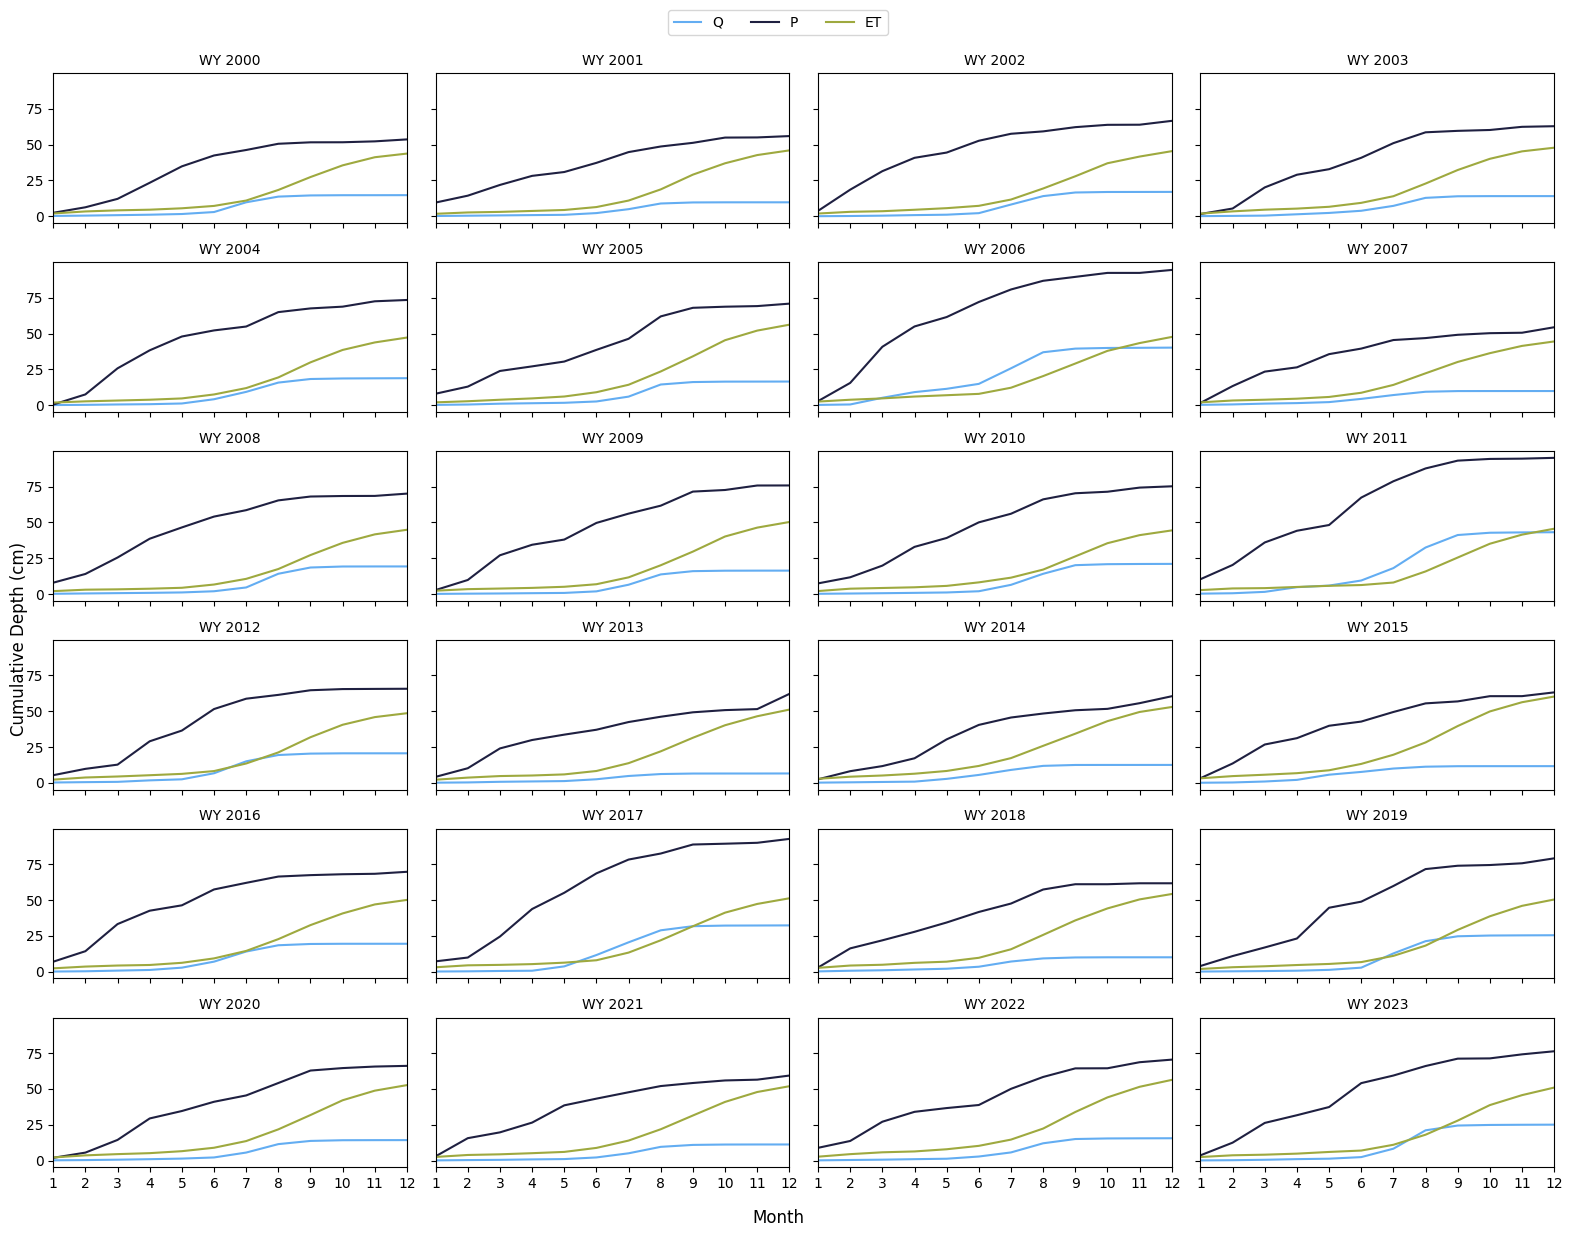

In [98]:
## plotting all water years at once
# parameters to loop through
years = list(range(2000, 2024)) # years to plot (excludes final year (2024))
n = len(years)
ncols = 4 # number of columns in plot
nrows = math.ceil(n / ncols) # number of rows in plot

# plotting
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Function to convert calendar dates to water-year month numbers to make x-axis cleaner
def wy_month(dates):
    return ((dates.month - 10) % 12) + 1

# looping through years to plot
for i, wy in enumerate(years):

    ax = axes[i]

    # pulling out each year
    Q_wy  = Q_cum[Q_cum['water_year'] == wy]
    P_wy  = P_cum[P_cum['water_year'] == wy]
    ET_wy = ET_cum[ET_cum['water_year'] == wy]

    if len(P_wy) == 0 or len(Q_wy) == 0 or len(ET_wy) == 0:
        ax.set_visible(False)
        continue

    # Convert index to month numbers
    Q_months  = wy_month(Q_wy.index)
    P_months  = wy_month(P_wy.index)
    ET_months = wy_month(ET_wy.index)

    # Plot using month numbers
    ax.plot(Q_months,  Q_wy['cumulative'],  color='#63ADF2')
    ax.plot(P_months,  P_wy['cumulative'],  color='#1F2041')
    ax.plot(ET_months, ET_wy['cumulative'], color='#9EA93F')

    # labeling
    ax.set_title(f'WY {wy}', fontsize=10) # title for each water year plot
    ax.set_xlim(1, 12) # setting each x lim to show each month of water year
    ax.set_xticks(range(1, 13)) # adding ticks

# labeling larger figure
fig.supylabel('Cumulative Depth (cm)')
fig.supxlabel('Month')
fig.legend(['Q', 'P', 'ET'],ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.show()

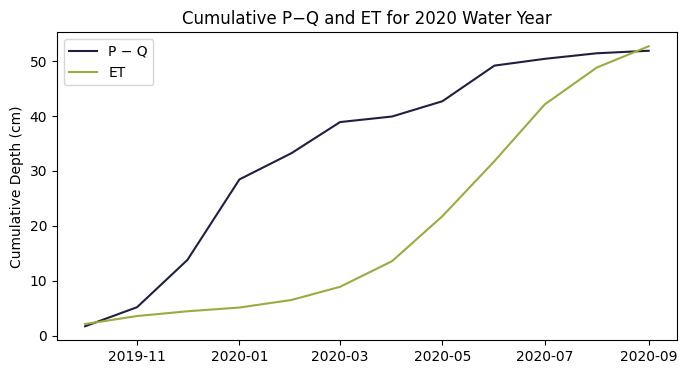

In [99]:
## plotting cumulative P−Q and ET for one select water year
wy = 2020  # change year here

# filtering so that only the designated water year is used
Q_cum_wy  = Q_cum[Q_cum['water_year'] == wy]
P_cum_wy  = P_cum[P_cum['water_year'] == wy]
ET_cum_wy = ET_cum[ET_cum['water_year'] == wy]

# compute P − Q cumulative difference
PQ_diff = P_cum_wy['cumulative'] - Q_cum_wy['cumulative']

# plotting
plt.figure(figsize=(8, 4))

# P − Q curve
plt.plot(P_cum_wy.index, PQ_diff,
         label='P − Q', color='#1F2041')

# ET cumulative curve
plt.plot(ET_cum_wy.index, ET_cum_wy['cumulative'],
         label='ET', color='#9EA93F')

# labeling
plt.ylabel('Cumulative Depth (cm)')
plt.title(f'Cumulative P−Q and ET for {wy} Water Year')
plt.legend()
plt.show()

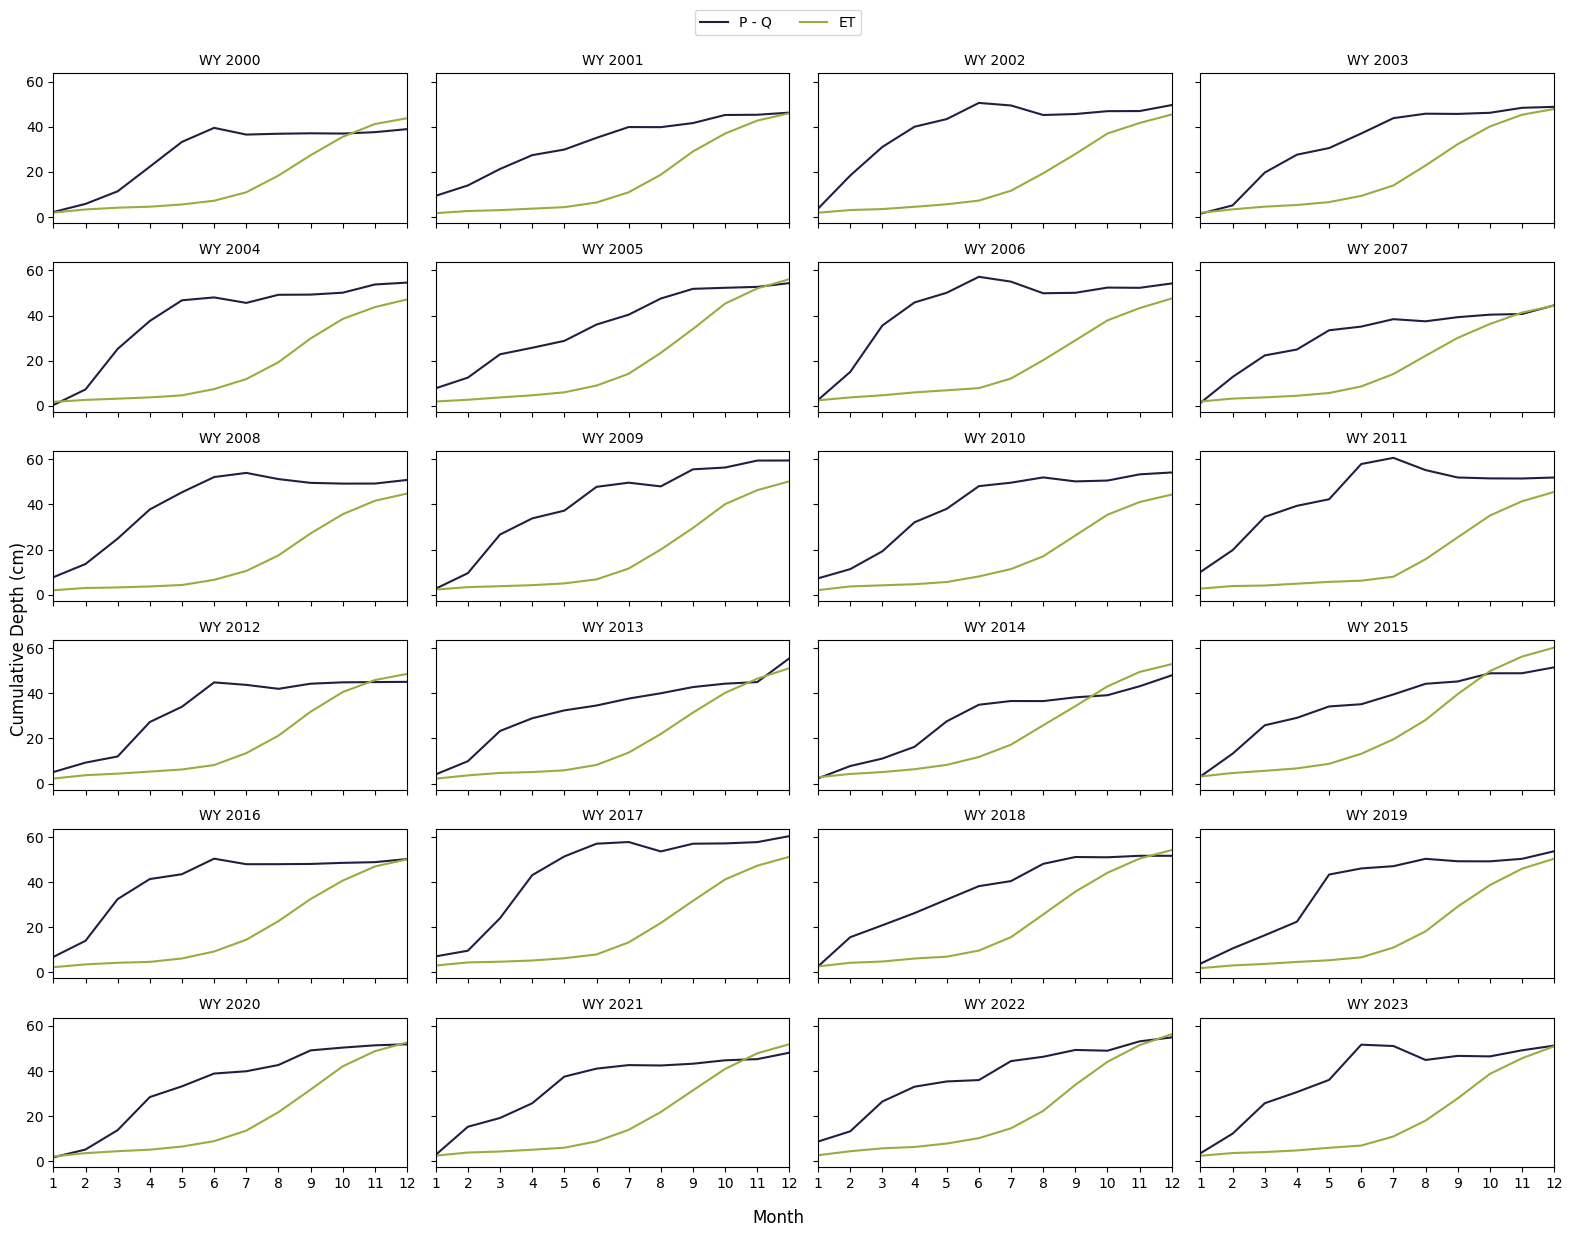

In [97]:
## plotting all water years at once
# parameters to loop through
years = list(range(2000, 2024)) # years to plot (excludes final year (2024))
n = len(years)
ncols = 4 # number of columns in plot
nrows = math.ceil(n / ncols) # number of rows in plot

# plotting
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Function to convert calendar dates to water-year month numbers to make x-axis cleaner
def wy_month(dates):
    return ((dates.month - 10) % 12) + 1

# looping through years to plot
for i, wy in enumerate(years):

    ax = axes[i]

    # pulling out each year
    Q_wy  = Q_cum[Q_cum['water_year'] == wy]
    P_wy  = P_cum[P_cum['water_year'] == wy]
    ET_wy = ET_cum[ET_cum['water_year'] == wy]

    # skipping empty years
    if len(P_wy) == 0 or len(Q_wy) == 0 or len(ET_wy) == 0:
        ax.set_visible(False)
        continue

    # compute P - Q cumulative difference
    diff_PQ = P_wy['cumulative'] - Q_wy['cumulative']

    # convert dates to WY month numbers
    months = wy_month(P_wy.index)

    # plot P - Q
    ax.plot(months, diff_PQ, color='#1F2041', label='P − Q')

    # plot ET
    ax.plot(months, ET_wy['cumulative'], color='#9EA93F', label='ET')

    ax.set_title(f'WY {wy}', fontsize=10)
    ax.set_xlim(1, 12)
    ax.set_xticks(range(1, 13))


    # labeling
    ax.set_title(f'WY {wy}', fontsize=10) # title for each water year plot
    ax.set_xlim(1, 12) # setting each x lim to show each month of water year
    ax.set_xticks(range(1, 13)) # adding ticks

# labeling larger figure
fig.supylabel('Cumulative Depth (cm)')
fig.supxlabel('Month')
fig.legend(['P - Q', 'ET'],ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.show()

In [104]:
## calculating the number of months per year where ET > P-Q
water_years = range(2000, 2024) # years (excludes final year (2024))
results = []

# looping through each year
for wy in water_years:

    # pull out water year
    P_wy = P_cum[P_cum['water_year'] == wy].copy()
    Q_wy = Q_cum[Q_cum['water_year'] == wy].copy()

    # skip empty years
    if len(P_wy) == 0 or len(Q_wy) == 0:
        continue

    # compute P − Q cumulative difference
    P_wy['PQ_cum'] = P_wy['cumulative'] - Q_wy['cumulative']

    # compute slope (month-to-month change)
    P_wy['slope'] = P_wy['PQ_cum'].diff()

    # group by calendar month
    monthly = P_wy.groupby(P_wy.index.to_period('M'))['slope']

    # Count months where mean slope < 0
    neg_months = (monthly.mean() < 0).sum()

    # appending results
    results.append({
        'water_year': wy,
        'neg_months': int(neg_months)
    })

neg_months_df = pd.DataFrame(results) # adding results of each year to data fram
print(neg_months_df) # printing

    water_year  neg_months
0         2000           2
1         2001           1
2         2002           2
3         2003           1
4         2004           1
5         2005           0
6         2006           3
7         2007           1
8         2008           3
9         2009           1
10        2010           1
11        2011           4
12        2012           2
13        2013           0
14        2014           1
15        2015           0
16        2016           1
17        2017           1
18        2018           2
19        2019           2
20        2020           0
21        2021           1
22        2022           1
23        2023           3


# P, Q, ET anomalies

In [133]:
## calculating annual water budget anomalies
# Q
Q_mean = Q_cm_ann.mean() # calculating Q mean
Q_anomaly = Q_cm_ann - Q_mean # calculating Q anomaly

# ET
ET_mean = ET_cm_ann.mean() # calculating ET mean
ET_anomaly = ET_cm_ann - ET_mean # calculating ET anomaly

# P
P_mean = P_cm_ann.mean() # calculating P mean
P_anomaly = P_cm_ann - P_mean # calculating P anomaly

# merging into one dataframe
anomalies_df = pd.DataFrame({'water_year': Q_yr,'Q_anomaly': Q_anomaly,'ET_anomaly': ET_anomaly, 'P_anomaly': P_anomaly})

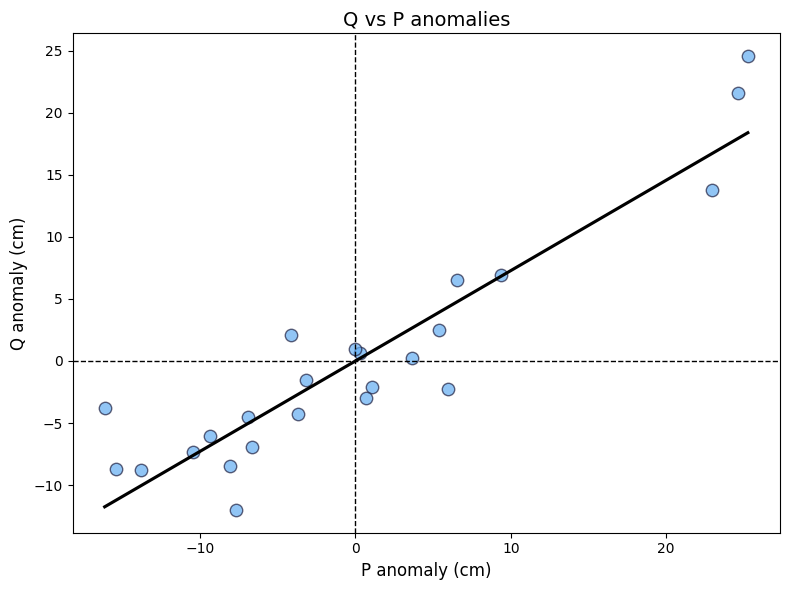

Correlation between Q anomaly and P anomaly: r = 0.92, p = 0.0000000001


In [134]:
## plotting P and Q anomalies
# plotting with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='P_anomaly', y='Q_anomaly', data=anomalies_df, ci=None, scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#63ADF2', 'edgecolor': '#1F2041'}, line_kws={'color': 'black'})
plt.axhline(0, color='black', linewidth=1, linestyle='--') # add horizontal zero reference line
plt.axvline(0, color='black', linewidth=1, linestyle='--') # add vertical zero reference line

# labeling
plt.xlabel('P anomaly (cm)', fontsize=12)
plt.ylabel('Q anomaly (cm)', fontsize=12)
plt.title(f'Q vs P anomalies', fontsize=14)
plt.tight_layout()
plt.show()

# correlations coefficient
r, p = pearsonr(P_anomaly, Q_anomaly)
print(f'Correlation between Q anomaly and P anomaly: r = {r:.2f}, p = {p:.10f}')

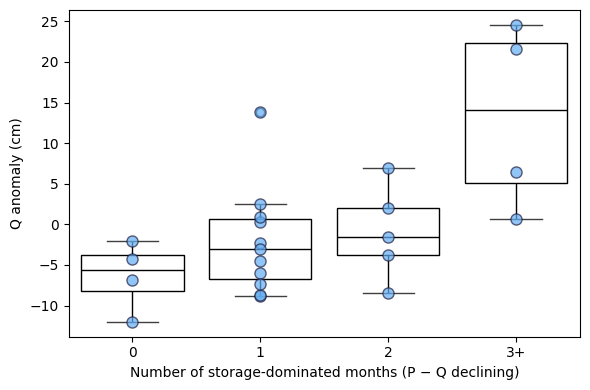

In [143]:
## plotting Q anomalies by the number of months where ET > P-Q
# merging Q anomalies with neg_months_df
merged_negQ = pd.merge(neg_months_df, anomalies_df[["water_year", "Q_anomaly"]],on="water_year",how="inner")

# binning negative months into categories
def categorize(n):
    if n == 0:
        return "0" # 0 months
    elif n == 1:
        return "1" # 1 month
    elif n == 2:
        return "2" # 2 months
    else:
        return "3+" # 3 months

merged_negQ["neg_months_cat"] = merged_negQ["neg_months"].apply(categorize)

# putting bins/categories in order
cat_order = ["0", "1", "2", "3+"]
merged_negQ["neg_months_cat"] = pd.Categorical(merged_negQ["neg_months_cat"], categories=cat_order, ordered=True)

# plotting boxplots of each bin/category
plt.figure(figsize=(6,4))

# boxplot
sns.boxplot(data=merged_negQ,x="neg_months_cat",y="Q_anomaly",showcaps=True,boxprops={'facecolor':'None', 'edgecolor':'black'},whiskerprops={'color':'black'},medianprops={'color':'black'}) # transparent boxplot to see points
# overlaying points
sns.stripplot(data=merged_negQ,x="neg_months_cat",y="Q_anomaly",jitter=False,size=8,color="#63ADF2",edgecolor='#1F2041',linewidth=1,alpha=0.7)

# labeling
plt.xlabel("Number of storage-dominated months (P − Q declining)")
plt.ylabel("Q anomaly (cm)")
plt.tight_layout()
plt.show()

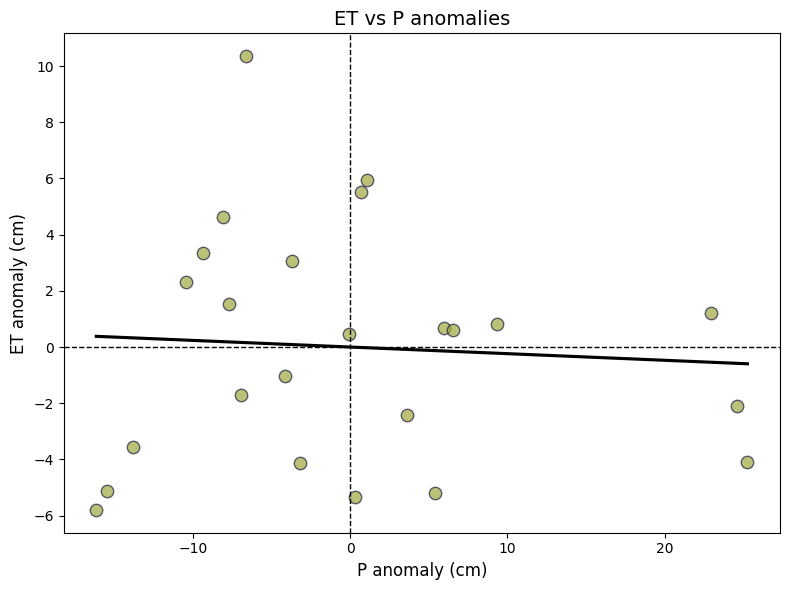

Correlation between ET anomaly and P anomaly: r = -0.07, p = 0.7601007473


In [131]:
## plotting P and ET anomalies
# plotting with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='P_anomaly', y='ET_anomaly', data=anomalies_df, ci=None, scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#9EA93F', 'edgecolor': '#1F2041'}, line_kws={'color': 'black'})
plt.axhline(0, color='black', linewidth=1, linestyle='--') # add horizontal zero reference line
plt.axvline(0, color='black', linewidth=1, linestyle='--') # add vertical zero reference line

# labeling
plt.xlabel('P anomaly (cm)', fontsize=12)
plt.ylabel('ET anomaly (cm)', fontsize=12)
plt.title(f'ET vs P anomalies', fontsize=14)
plt.tight_layout()
plt.show()

# correlations coefficient
r, p = pearsonr(P_anomaly, ET_anomaly)
print(f'Correlation between ET anomaly and P anomaly: r = {r:.2f}, p = {p:.10f}')

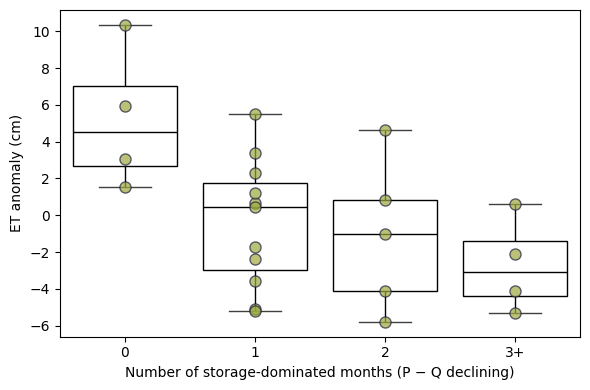

In [142]:
## plotting ET anomalies by the number of months where ET > P-Q
# merging ET anomalies with neg_months_df
merged_negET = pd.merge(neg_months_df, anomalies_df[["water_year", "ET_anomaly"]],on="water_year",how="inner")

# binning negative months into categories
def categorize(n):
    if n == 0:
        return "0" # 0 months
    elif n == 1:
        return "1" # 1 month
    elif n == 2:
        return "2" # 2 months
    else:
        return "3+" # 3 months

merged_negET["neg_months_cat"] = merged_negET["neg_months"].apply(categorize)

# putting bins/categories in order
cat_order = ["0", "1", "2", "3+"]
merged_negET["neg_months_cat"] = pd.Categorical(merged_negET["neg_months_cat"], categories=cat_order, ordered=True)

# plotting boxplots of each bin/category
plt.figure(figsize=(6,4))

# boxplot
sns.boxplot(data=merged_negET,x="neg_months_cat",y="ET_anomaly",showcaps=True,boxprops={'facecolor':'None', 'edgecolor':'black'},whiskerprops={'color':'black'},medianprops={'color':'black'}) # transparent boxplot to see points
# overlaying points
sns.stripplot(data=merged_negET,x="neg_months_cat",y="ET_anomaly",jitter=False,size=8,color="#9EA93F",edgecolor='#1F2041',linewidth=1,alpha=0.7)

# labeling
plt.xlabel("Number of storage-dominated months (P − Q declining)")
plt.ylabel("ET anomaly (cm)")
plt.tight_layout()
plt.show()

In [ ]:
##### TESTING SIGNIFIGANCE ##########

# Plotting indices

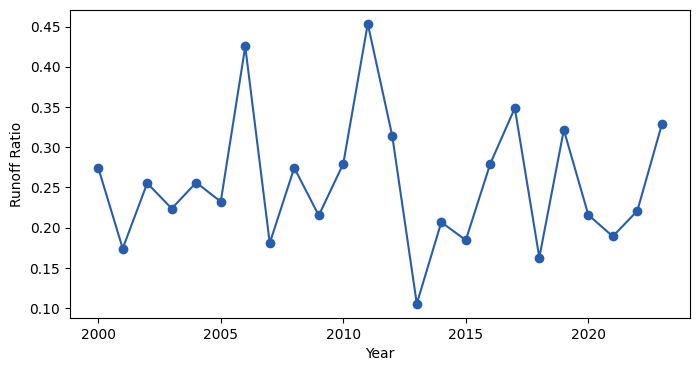

In [12]:
## plotting runoff ratio
runoff_ratio_fig = plt.figure(figsize=(8, 4))

runoff_ratio = Q_cm_ann / P_cm_ann # calculating runoff ratio
plt.plot(P_yr, runoff_ratio, marker='o', color='#275DAD') # plotting runoff ratio

# adding labels
plt.xlabel('Year')
plt.ylabel('Runoff Ratio')

runoff_ratio_fig.savefig('runoff_ratio.png') # saving figure

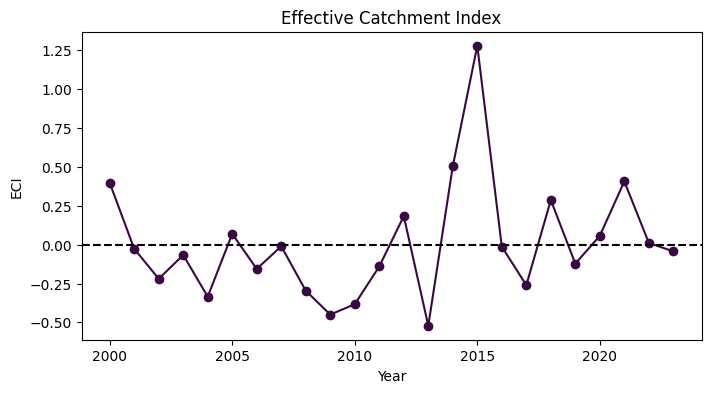

In [13]:
## effective catchment index (ECI): positive implies catchment is gaining water for the respective year, negative implies that the catchment is losing water
ECI = np.log(Q_cm_ann / (P_cm_ann - ET_cm_ann)) # calculating ECI

ECI_fig = plt.figure(figsize=(8, 4))

plt.plot(ET_yr, ECI, marker='o', color='#3A0842') # plotting ECI
plt.axhline(y=0, color='k', linestyle='--') # plotting horizontal line at zero

# labeling
plt.title('Effective Catchment Index')
plt.xlabel('Year')
plt.ylabel('ECI')

ECI_fig.savefig('ECI.png') # saving figure

# Snow and P temp

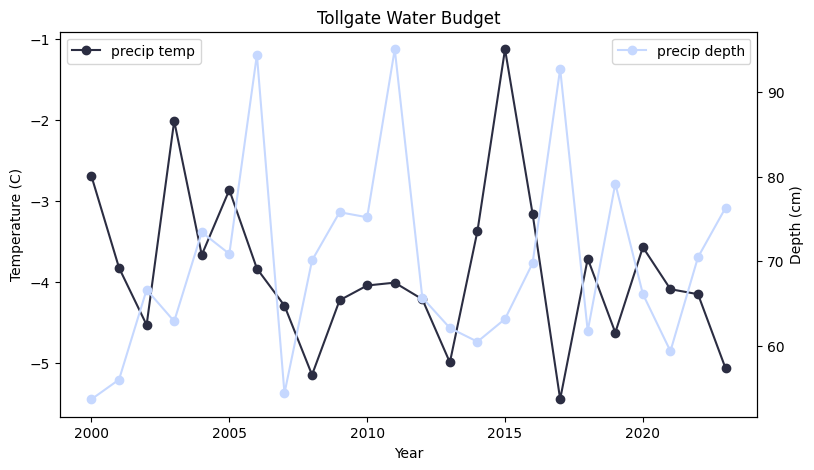

In [14]:
## plotting P temp and P depth
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(P_temp_yr, P_temp_C, label='precip temp', marker='o', color='#2B2D42')
ax1.set_ylabel('Temperature (C)')
ax1.set_xlabel('Year')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(P_yr, P_cm_ann, label='precip depth', marker='o', color='#C6D8FF')
ax2.set_ylabel('Depth (cm)')
ax2.legend(loc='upper right')

plt.title('Tollgate Water Budget')
plt.show()

In [15]:
## to add once I get the data sorted out ##